In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#Load Dataset

In [ ]:
df = pd.read_csv("/content/Loan.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#Inspect Dataset

In [ ]:
df.info()

df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

#Check Missing Values


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


#Drop Loan_ID

In [ ]:
df.drop("Loan_ID", axis=1, inplace=True)

#Handle Missing Values

In [ ]:
cat_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
num_cols = [
    'LoanAmount',
    'Loan_Amount_Term'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [ ]:
#credit history

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

#Feature Engineering

In [ ]:
#total income

df['total_income'] = (
    df['ApplicantIncome']
    +
    df['CoapplicantIncome']
)

In [ ]:
#loan income ratio

df['loan_income_ratio'] = (
    df['LoanAmount']
    /
    df['total_income']
)

In [ ]:
#convert dependents

df['Dependents'] = df['Dependents'].replace('3+',3)

df['Dependents'] = df['Dependents'].astype(int)

#Encode Target

In [ ]:
df['Loan_Status'] = df['Loan_Status'].map({
    'Y':1,
    'N':0
})

#One-Hot Encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'Married',
        'Education',
        'Self_Employed',
        'Property_Area'
    ],
    drop_first=True
)

#EDA

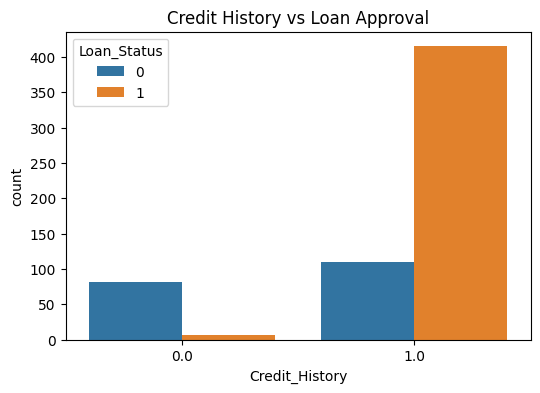

In [ ]:
#Credit History vs Loan Approval

plt.figure(figsize=(6,4))

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.title("Credit History vs Loan Approval")
plt.show()

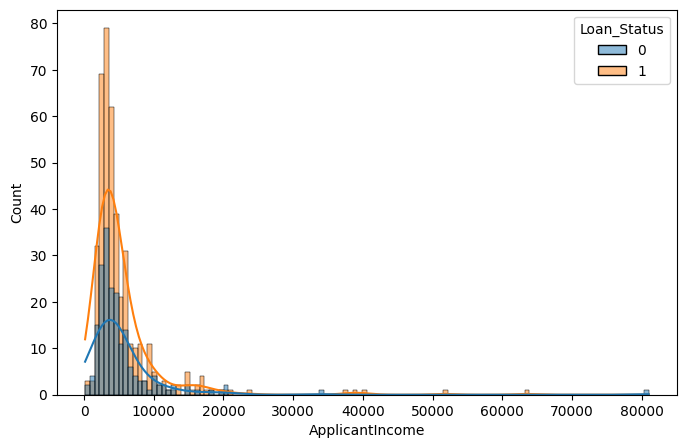

In [ ]:
#Applicant Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='ApplicantIncome',
    hue='Loan_Status',
    kde=True
)

plt.show()

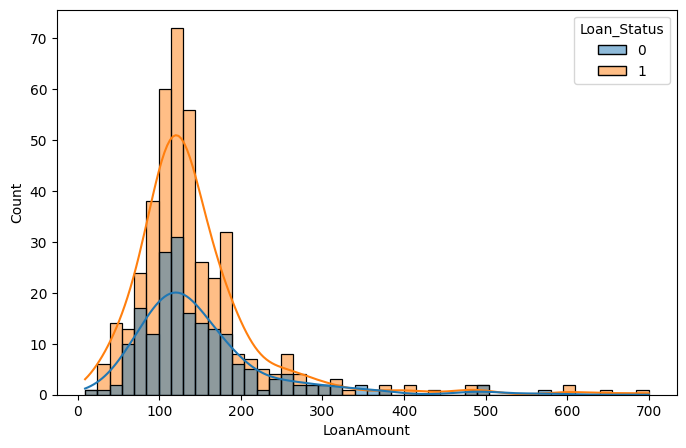

In [ ]:
#Loan Amount Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='LoanAmount',
    hue='Loan_Status',
    kde=True
)

plt.show()

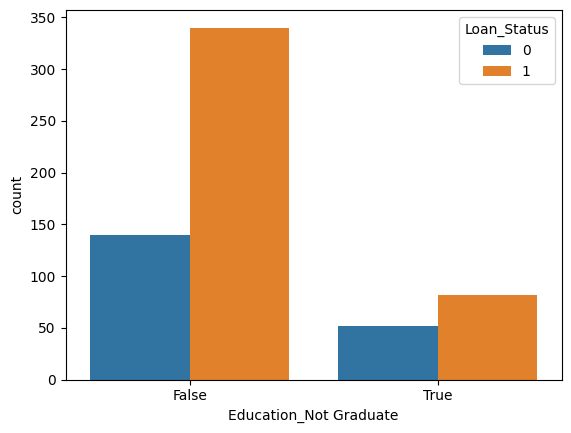

In [ ]:
#Approval Rate by Education

sns.countplot(
    x='Education_Not Graduate',
    hue='Loan_Status',
    data=df
)

plt.show()

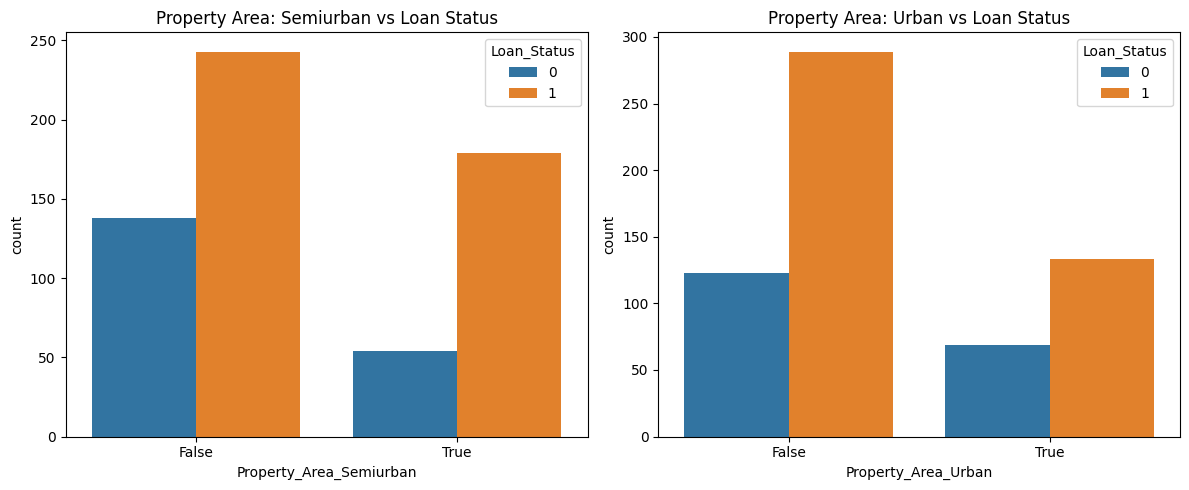

In [ ]:
#Property Area (One-Hot Encoded)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(
    x='Property_Area_Semiurban',
    hue='Loan_Status',
    data=df
)
plt.title('Property Area: Semiurban vs Loan Status')

plt.subplot(1, 2, 2)
sns.countplot(
    x='Property_Area_Urban',
    hue='Loan_Status',
    data=df
)
plt.title('Property Area: Urban vs Loan Status')

plt.tight_layout()
plt.show()

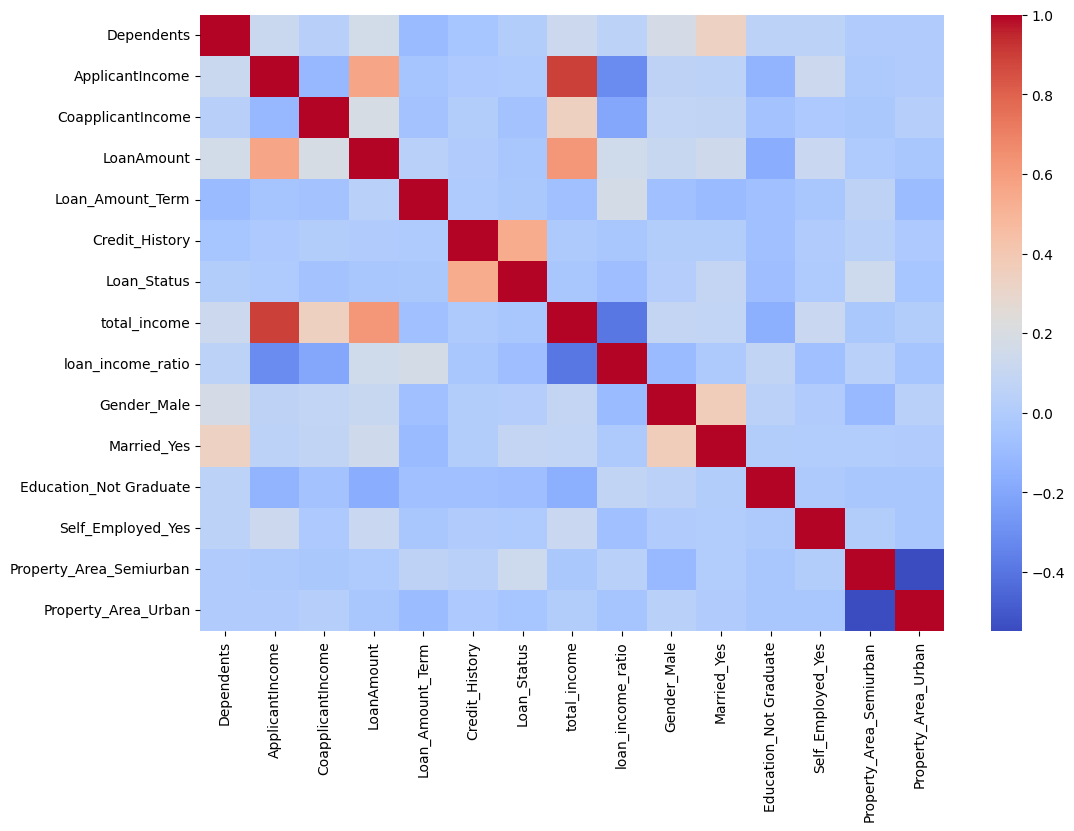

In [ ]:
#Correlation Heatmap


plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.show()

#Split Features

In [ ]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

#Train-Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Train Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

#Prediction

In [ ]:
y_pred = model.predict(X_test)

#Evaluation

In [ ]:
#accuracy

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy*100)

Accuracy: 85.36585365853658


In [ ]:
#precision

precision = precision_score(y_test,y_pred)

print("Precision:",precision*100)

Precision: 83.83838383838383


In [ ]:
#recall

recall = recall_score(y_test,y_pred)

print("Recall:",recall*100)

Recall: 97.6470588235294


In [ ]:
#f1 score

f1 = f1_score(y_test,y_pred)

print("F1 Score:",f1*100)

F1 Score: 90.21739130434783


In [ ]:
#classification report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



#Confusion Matrix

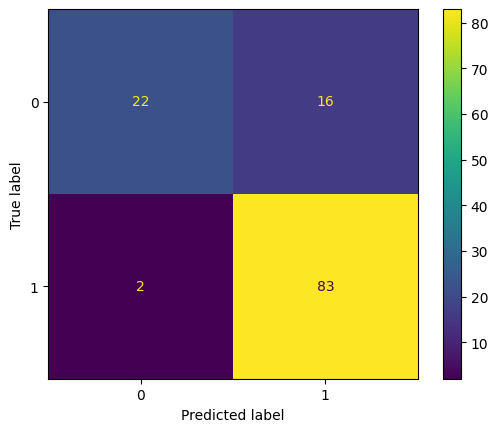

In [ ]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

#Coefficient Analysis

In [ ]:
coefficients = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                    Feature  Coefficient
5            Credit_History     3.229424
12  Property_Area_Semiurban     0.642487
9               Married_Yes     0.642070
0                Dependents     0.106541
13      Property_Area_Urban     0.076778
1           ApplicantIncome     0.000017
6              total_income    -0.000019
2         CoapplicantIncome    -0.000036
3                LoanAmount    -0.000621
4          Loan_Amount_Term    -0.000665
7         loan_income_ratio    -0.076015
8               Gender_Male    -0.167196
11        Self_Employed_Yes    -0.227921
10   Education_Not Graduate    -0.390812


#Conclusion

1. Successfully cleaned the dataset by handling missing values and removing unnecessary columns.

2. Performed feature engineering by creating:
   - Total Income
   - Loan Income Ratio

3. Converted categorical variables into numerical form using one-hot encoding.

4. Trained a Logistic Regression model to predict loan approval status.

5. Evaluated the model using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

6. Feature coefficient analysis showed that Credit_History is the most influential factor
   for loan approval. Applicants with a good credit history have a much higher chance
   of getting their loan approved.

7. Other important factors include Total Income, Loan Income Ratio, Education,
   and Property Area.

   

Overall, the Logistic Regression model provides an effective and interpretable solution
for predicting loan approval, making it useful for assisting banks in their initial
loan screening process.
""")